In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "Arial"

from pingouin import partial_corr

from func_data_prep import get_var_type, get_var_type_color, process_string

import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

/Users/rohansingh/miniconda3/envs/openai_di/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## 

In [2]:
meta = pd.read_csv("../data/meta_meal_patterns.csv")

meta["HEI_Quartile"] = pd.Categorical(
    meta["HEI_Quartile"], categories=["Q1", "Q2", "Q3", "Q4"], ordered=True
)
meta["daily_HEI_Quartile"] = pd.Categorical(
    meta["daily_HEI_Quartile"], categories=["Q1", "Q2", "Q3", "Q4"], ordered=True
)
meta["bmi_cat"] = pd.Categorical(
    meta["bmi_cat"],
    categories=["Underweight", "Normal", "Overweight", "Obese"],
    ordered=True,
)
meta["age_group_2"] = pd.Categorical(
    meta["age_group_2"], categories=["<35", "35-50", ">50"], ordered=True
)

In [3]:
merged_meals_with_meta = pd.read_pickle("../data/merged_meals_with_meta.pkl")

## Partial Correlation

In [4]:
def plot_horizontal_nutri_ordered_partial_correlation(
    meta,
    target_var,
    ax,
    corr_threshold=0.2,
    covariates=["age", "bmi"],
    ignore_cols=[],
    show_legend=True,
    title=None,
):
    """
    Plot horizontal partial correlations between variables and a target variable, adjusted for covariates.

    Parameters:
    -----------
    meta : pandas.DataFrame
        Input dataframe containing the variables
    target_var : str
        Target variable to correlate against
    corr_threshold : float
        Minimum absolute correlation value to display
    covariates : list
        List of variables to adjust for in partial correlation
    ignore_cols : list
        List of columns to ignore in the correlation analysis
    figsize : tuple
        Figure size (width, height)
    """

    # Get all numeric columns
    numeric_cols = meta.select_dtypes(include=["float64", "int64"]).columns

    # Calculate partial correlations
    corrs_list = []
    for col in numeric_cols:
        if col != target_var and col not in ignore_cols and col not in covariates:
            try:
                # Calculate partial correlation
                pcorr = partial_corr(data=meta, x=col, y=target_var, covar=covariates)
                corrs_list.append(
                    {
                        "variable": col,
                        "r": pcorr["r"].values[0],
                        "p": pcorr["p-val"].values[0],
                    }
                )
            except Exception as e:
                print(f"Skipping {col} due to error: {e}")

    corrs = pd.DataFrame(corrs_list)

    # Remove energy_kj_eaten if present
    corrs = corrs[~corrs["variable"].isin(["energy_kj_eaten"])]

    # Add variable type classification
    corrs["var_type"] = corrs["variable"].apply(get_var_type)

    # Set the order for the var_type column
    var_type_order = [
        "Macronutrients",
        "Micronutrients",
        "Combined Food Groups",
        "Food Groups",
        "Diet Indices",
        "Temporal Patterns",
        "Anthropometrics",
        "Amounts",
        "Regularity Indices",
        "Others",
    ]

    corrs["var_type"] = pd.Categorical(
        corrs["var_type"], categories=var_type_order, ordered=True
    )
    corrs = corrs.sort_values(by=["var_type", "r"], ascending=[True, False])
    corrs["bar_color"] = corrs["var_type"].apply(get_var_type_color)

    # Filter by correlation threshold
    corrs = corrs[corrs["r"].abs() > corr_threshold]

    print(corrs.sort_values(by="r", ascending=False))

    # Create the plot
    sns.barplot(
        data=corrs,
        y="variable",
        x="r",
        orient="h",
        ax=ax,
        palette=list(corrs["bar_color"]),
        zorder=3,
    )

    # Customize the plot
    covar_str = ", ".join(covariates)
    ax.set_xlabel("Partial Correlation Coefficient (r)")
    ax.set_ylabel("")
    ax.set_yticklabels([process_string(var) for var in corrs["variable"]])
    # ax.set_title(
    #     f"Partial correlation with {process_string(target_var)}\n(adjusted for: {covar_str})",
    #     pad=10,
    # )

    ax.yaxis.grid(
        True, zorder=0, linestyle="--", linewidth=0.5, color="black", alpha=0.3
    )

    # Add legend for bar colors
    if show_legend:
        handles = []
        labels = []
        for var_type in corrs["var_type"].unique():
            color = get_var_type_color(var_type)
            handles.append(plt.Rectangle((0, 0), 1, 1, color=color))
            labels.append(var_type)
        ax.legend(
            handles,
            labels,
            title="Variable Type",
            bbox_to_anchor=(1.05, 1),
            loc="upper left",
            frameon=False,
        )

    if title:
        ax.set_title(title)

    return ax

In [5]:
print(partial_corr(data=meta, x="eo_freq", y="bmi", covar=["age", "energy_kcal_eaten"]))
print(partial_corr(data=meta, x="eo_freq", y="HEI", covar=["age", "bmi"]))
print(partial_corr(data=meta, x="eo_freq", y="daily_HEI", covar=["age", "bmi"]))

           n         r           CI95%     p-val
pearson  962 -0.120108  [-0.18, -0.06]  0.000191
           n         r         CI95%     p-val
pearson  962  0.128507  [0.07, 0.19]  0.000065
           n         r         CI95%         p-val
pearson  962  0.201905  [0.14, 0.26]  2.740593e-10


                             variable         r             p  \
118                          mean_dds  0.261613  1.798302e-16   
47                        sugar_eaten  0.259907  2.857163e-16   
121  mean_gini_simpson_diversity_kcal  0.256755  6.663432e-16   
120           mean_berger_parker_kcal  0.248328  6.060667e-15   
122                mean_quantidd_kcal  0.210582  4.496452e-11   
60                    fruits_fg_eaten  0.208655  6.796200e-11   
119       mean_shannon_diversity_kcal  0.206684  1.320193e-10   
22                      hPDI_Quintile  0.180954  1.670538e-08   
54                  vegetables_fruits  0.180154  1.935187e-08   
27                         carb_eaten  0.176211  3.957001e-08   
125                         daily_HEI  0.175471  4.517021e-08   
124                               HEI  0.171761  8.701410e-08   
21                       PDI_Quintile  0.170688  1.049238e-07   
30                        fiber_eaten  0.146048  5.592525e-06   
123            mean_mfad_

/var/folders/kl/wv2_2q3n4z3d2bxtztx97rgc0000gn/T/ipykernel_73399/3406239200.py:98: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([process_string(var) for var in corrs["variable"]])


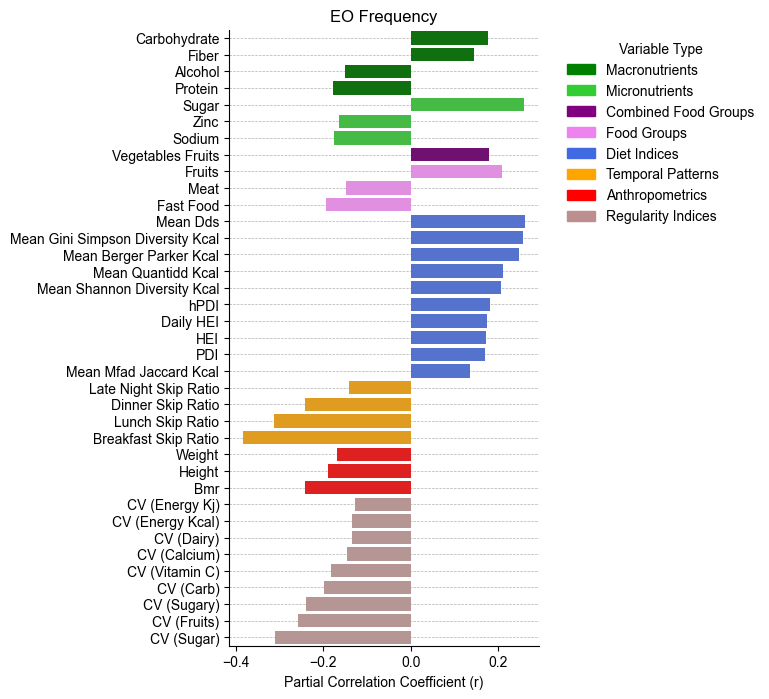

In [6]:
fig, ax = plt.subplots(figsize=(4, 8))
ax = plot_horizontal_nutri_ordered_partial_correlation(
    meta,
    target_var="eo_freq",
    ax=ax,
    corr_threshold=0.125,
    ignore_cols=[
        "alcohol_fg_eaten",
        "eo_space",
        "nova_cluster",
        "vitamin_b12_eaten",
        "vitamin_d_eaten",
        "mean_simpson_diversity_kcal",
    ],
    covariates=["age", "bmi", "energy_kcal_eaten"],
    title="EO Frequency",
)
sns.despine()
plt.savefig(
    "../images/fig1/eo_freq_partial_correlation.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.1,
)
plt.show()

                             variable         r             p  \
127                  Lunch_skip_ratio  0.323452  8.572085e-25   
95                     CV_sugar_eaten  0.287205  1.143746e-19   
104                CV_fruits_fg_eaten  0.243939  1.853508e-14   
15                                bmr  0.242519  2.648803e-14   
68                 fast_food_fg_eaten  0.205689  1.273731e-10   
14                             height  0.187791  4.626581e-09   
100                CV_vitamin_c_eaten  0.185838  6.708996e-09   
46                       sodium_eaten  0.181092  1.628415e-08   
13                             weight  0.180529  1.806471e-08   
107                CV_sugary_fg_eaten  0.177285  3.261319e-08   
108             CV_oils_nuts_fg_eaten  0.161204  5.208193e-07   
126              Breakfast_skip_ratio  0.158432  8.178650e-07   
115                 CV_water_fg_eaten  0.157805  9.047214e-07   
29                      protein_eaten  0.155667  1.272939e-06   
81                   CV_c

/var/folders/kl/wv2_2q3n4z3d2bxtztx97rgc0000gn/T/ipykernel_73399/3406239200.py:98: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([process_string(var) for var in corrs["variable"]])


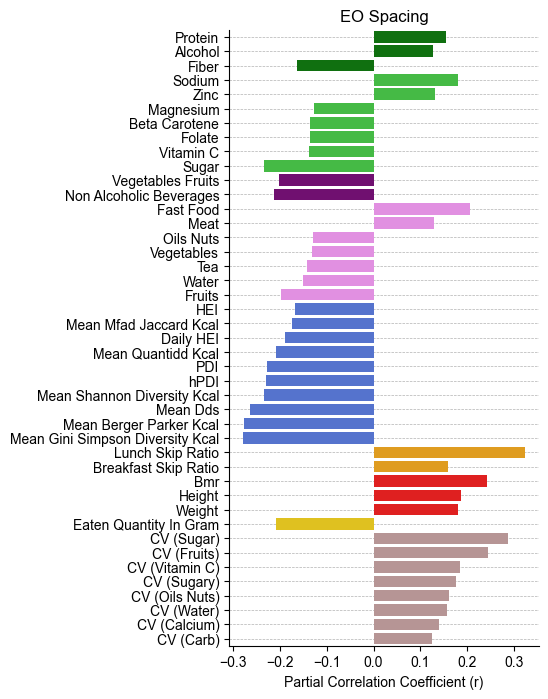

In [7]:
fig, ax = plt.subplots(figsize=(4, 8))
ax = plot_horizontal_nutri_ordered_partial_correlation(
    meta,
    target_var="eo_space",
    ax=ax,
    corr_threshold=0.125,
    ignore_cols=[
        "alcohol_fg_eaten",
        "eo_freq",
        "nova_cluster",
        "vitamin_b12_eaten",
        "vitamin_d_eaten",
        "mean_simpson_diversity_kcal",
    ],
    covariates=["age", "bmi", "energy_kcal_eaten"],
    show_legend=False,
    title="EO Spacing",
)
sns.despine()
plt.savefig(
    "../images/fig1/eo_space_partial_correlation.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.1,
)
plt.show()

                             variable         r             p  \
99                     CV_sugar_eaten  0.277038  2.244979e-18   
117                 CV_bread_fg_eaten  0.274876  4.199742e-18   
79                      CV_carb_eaten  0.249618  4.206505e-15   
125       mean_simpson_diversity_kcal  0.223391  2.538794e-12   
132                          eo_space  0.219823  5.718393e-12   
108                CV_fruits_fg_eaten  0.207945  7.728393e-11   
123       mean_shannon_diversity_kcal -0.200102  4.997034e-10   
126  mean_gini_simpson_diversity_kcal -0.223391  2.538794e-12   
48                        sugar_eaten -0.230608  4.706039e-13   
72                     bread_fg_eaten -0.232147  3.260462e-13   
122                          mean_dds -0.252356  2.061168e-15   
28                         carb_eaten -0.268447  2.616900e-17   
4                morning_hunger_level -0.279850  9.858795e-19   
131                           eo_freq -0.424667  2.576755e-43   

               var_type 

/var/folders/kl/wv2_2q3n4z3d2bxtztx97rgc0000gn/T/ipykernel_73399/3406239200.py:98: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([process_string(var) for var in corrs["variable"]])


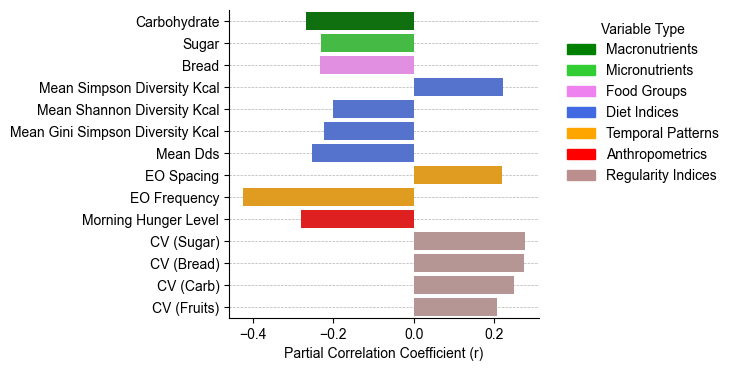

In [8]:
fig, ax = plt.subplots(figsize=(4, 4))
# plot_horizontal_nutri_ordered_correlation(meta, target_var='Breakfast_skip_ratio', corr_threshold=0.2, figsize=(4,4), ignore_cols=[])
plot_horizontal_nutri_ordered_partial_correlation(
    meta,
    target_var="Breakfast_skip_ratio",
    ax=ax,
    corr_threshold=0.2,
    ignore_cols=[],
    covariates=["age", "bmi"],
)
sns.despine()
plt.savefig(
    "../images/supplementary/breakfast_skip_ratio_correlation.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.1,
)
plt.show()

In [9]:
def plot_eo_freq_vs_feature_horizontal(
    meta, feature, hue_col="age_group_2", col_col="gender", show_legend=True
):
    unique_hues = meta[hue_col].unique()
    unique_cols = meta[col_col].unique()

    # Define a custom color palette
    palette = [
        "forestgreen",
        "orange",
        "red",
        "blue",
        "magenta",
    ]  # sns.color_palette("Set1", len(unique_hues)) #
    hue_color_map = dict(zip(unique_hues, palette))

    fig, axes = plt.subplots(
        1, len(unique_cols), figsize=(5 * len(unique_cols), 4), sharey=False
    )

    for i, col_value in enumerate(unique_cols):
        ax = axes[i] if len(unique_cols) > 1 else axes
        subset_col = meta[meta[col_col] == col_value]

        for hue_value in unique_hues:
            subset = subset_col[subset_col[hue_col] == hue_value]
            sns.regplot(
                data=subset,
                x=feature,
                y="eo_freq",
                ax=ax,
                label=hue_value,
                scatter_kws={"s": 20, "color": hue_color_map[hue_value]},
                line_kws={"color": hue_color_map[hue_value]},
            )

            # Calculate the correlation coefficient
            if not subset.empty:
                r_value = subset[[feature, "eo_freq"]].corr().iloc[0, 1]
                ax.annotate(
                    f"{hue_value}: R = {r_value:.2f}",
                    xy=(0.05, 0.95 - 0.06 * unique_hues.tolist().index(hue_value)),
                    xycoords="axes fraction",
                    fontsize=11,
                    ha="left",
                    va="top",
                    color=hue_color_map[hue_value],
                )

        ax.set_title(f"{process_string(col_col)}: {col_value}")
        ax.set_xlabel(process_string(feature))
        ax.set_ylabel(process_string("eo_freq"))

    # Create a single legend for all subplots
    if show_legend:
        handles, labels = ax.get_legend_handles_labels()
        fig.legend(
            handles,
            labels,
            title=process_string(hue_col),
            loc="upper right",
            bbox_to_anchor=(1, 0.7),
            frameon=False,
        )

    plt.tight_layout(
        rect=[0, 0, 0.9, 1], w_pad=4.0
    )  # Adjust layout to make space for the legend and add space between subplots
    sns.despine()

    return fig, ax

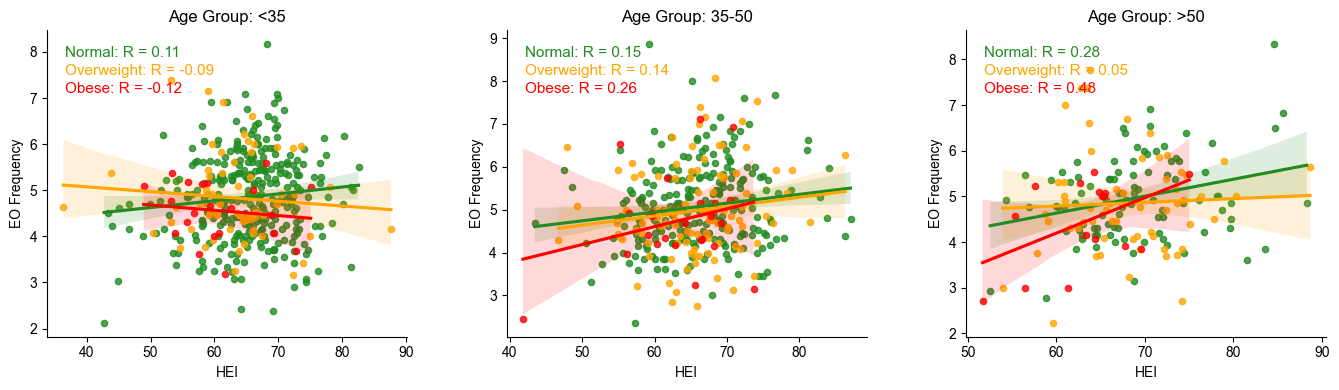

In [10]:
fig, ax = plot_eo_freq_vs_feature_horizontal(
    meta[meta["bmi_cat"] != "Underweight"],
    "HEI",
    hue_col="bmi_cat",
    col_col="age_group_2",
    show_legend=False,
)

fig.savefig(
    "../images/fig1/eo_freq_vs_HEI_horizontal.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.1,
)

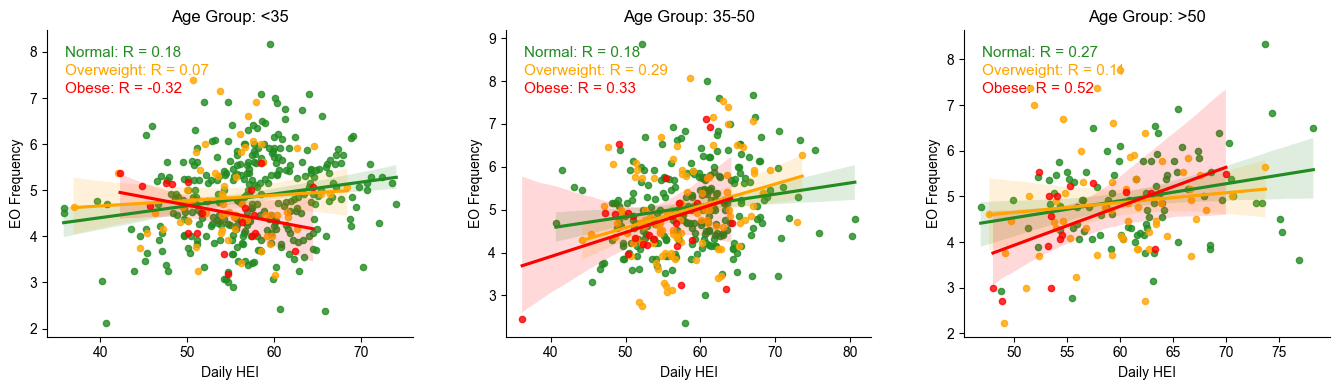

In [11]:
fig, ax = plot_eo_freq_vs_feature_horizontal(
    meta[meta["bmi_cat"] != "Underweight"],
    "daily_HEI",
    hue_col="bmi_cat",
    col_col="age_group_2",
    show_legend=False,
)

fig.savefig(
    "../images/fig1/eo_freq_vs_daily_HEI_horizontal.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.1,
)

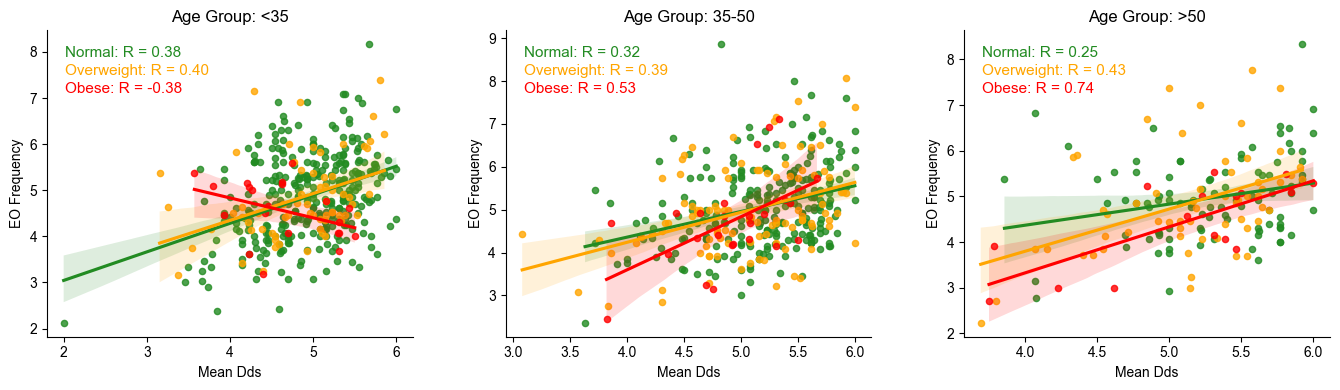

In [12]:
fig, ax = plot_eo_freq_vs_feature_horizontal(
    meta[meta["bmi_cat"] != "Underweight"],
    "mean_dds",
    hue_col="bmi_cat",
    col_col="age_group_2",
    show_legend=False,
)

fig.savefig(
    "../images/fig1/eo_freq_vs_mean_dds_horizontal.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.1,
)

## Meal Presence


In [13]:
def get_windowed_presence(group, window_size=1):
    """
    Calculate the presence of meals in specified time windows.

    Parameters:
    group (pd.DataFrame): DataFrame containing 'eaten_hour' column.
    window_size (int): The size of the time window in hours.

    Returns:
    pd.Series: A series indicating the presence of meals in each time window.
    """
    # Calculate the number of windows in a day
    num_windows = 24 // window_size
    # Initialize a series with zeros for each window
    windowed_range = pd.Series(0, index=np.arange(0, num_windows))

    # Mark the windows where meals were eaten as 1
    for hour in group["eaten_hour"]:
        window_index = hour // window_size
        windowed_range[window_index] = 1

    return windowed_range


mmm_no_small = merged_meals_with_meta[merged_meals_with_meta["energy_kcal_eaten"] > 0]
# mmm_no_small = mmm_no_small[
#     ~(mmm_no_small["combined_name"].apply(lambda x: "Tag standardised meal" in x))
# ]

windowed_presence = mmm_no_small.groupby(["subject_key", "eaten_date"]).apply(
    lambda x: get_windowed_presence(x, window_size=1)
)

/var/folders/kl/wv2_2q3n4z3d2bxtztx97rgc0000gn/T/ipykernel_73399/653505893.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  windowed_presence = mmm_no_small.groupby(["subject_key", "eaten_date"]).apply(


In [14]:
windowed_presence_mean = (
    windowed_presence.reset_index()
    .drop(columns=["eaten_date"])
    .groupby(["subject_key"])
    .mean()
    .reset_index()
)

In [15]:
def plot_eo_freq_by_hour(
    meta_df, windowed_presence_mean, ax, infrequent_cutoff=3.5, frequent_cutoff=6.5
):
    """
    Analyze and visualize meal timing distribution for infrequent and frequent consumers.

    Parameters:
    -----------
    meta_df : pandas.DataFrame
        DataFrame containing metadata with columns 'subject_key' and 'eo_freq'
    windowed_presence_mean : pandas.DataFrame
        DataFrame containing windowed presence data with 'subject_key' and hour columns
    infrequent_cutoff : float, optional (default=3.5)
        Upper threshold for infrequent consumers
    frequent_cutoff : float, optional (default=6.5)
        Lower threshold for frequent consumers
    figsize : tuple, optional (default=(12, 4))
        Figure size for the plot

    Returns:
    --------
    tuple : (matplotlib.figure.Figure, pandas.DataFrame)
        Returns the created figure and the processed DataFrame
    """
    # Get consumer groups
    infrequent_consumers = meta_df[meta_df["eo_freq"] < infrequent_cutoff][
        "subject_key"
    ].values.tolist()
    frequent_consumers = meta_df[meta_df["eo_freq"] > frequent_cutoff][
        "subject_key"
    ].values.tolist()

    # Filter data for extreme consumers
    windowed_presence_mean_extreme = windowed_presence_mean[
        windowed_presence_mean["subject_key"].isin(
            infrequent_consumers + frequent_consumers
        )
    ].copy()

    # Add consumer group labels
    windowed_presence_mean_extreme["consumer_group"] = np.where(
        windowed_presence_mean_extreme["subject_key"].isin(
            meta_df[meta_df["eo_freq"] < infrequent_cutoff]["subject_key"].values
        ),
        f"Infrequent (n={len(infrequent_consumers)})",
        f"Frequent (n={len(frequent_consumers)})",
    )

    # Melt the DataFrame
    melted_windowed_presence = windowed_presence_mean_extreme.melt(
        id_vars=["subject_key", "consumer_group"],
        var_name="Hour",
        value_name="Meal Presence",
    )

    # Process hour column and sort
    melted_windowed_presence["Hour"] = melted_windowed_presence["Hour"].astype(int)
    melted_windowed_presence = melted_windowed_presence.sort_values(
        "consumer_group", ascending=False
    )

    # Print group sizes (optional, can be removed if not needed)
    print("Number of subjects in each group:")
    print(melted_windowed_presence.groupby("consumer_group")["subject_key"].nunique())

    sns.boxplot(
        data=melted_windowed_presence,
        x="Hour",
        y="Meal Presence",
        palette=["#FA8072", "#9370DB"],
        hue="consumer_group",
        ax=ax,
        fliersize=2,
        linewidth=0.5,
    )

    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Meal Presence")
    ax.legend(title="Consumer Group", frameon=False)

    return ax, infrequent_consumers, frequent_consumers

Number of subjects in each group:
consumer_group
Frequent (n=108)     108
Infrequent (n=55)     55
Name: subject_key, dtype: int64


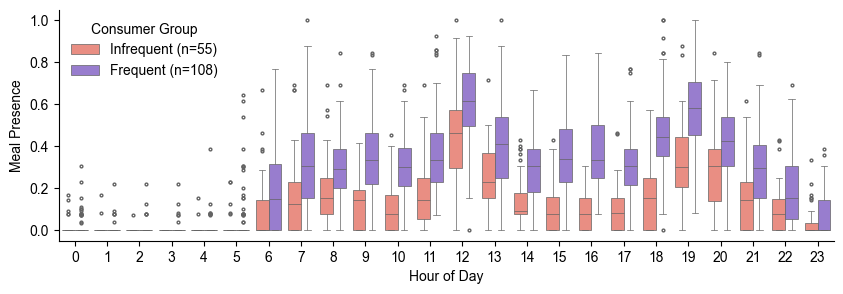

In [16]:
infrequent_cutoff = 3.5
frequent_cutoff = 6

fig, ax = plt.subplots(figsize=(10, 3))
ax, infrequent_consumers, frequent_consumers = plot_eo_freq_by_hour(
    # meta, windowed_presence_mean, ax, infrequent_cutoff=3.5, frequent_cutoff=6.5
    meta,
    windowed_presence_mean,
    ax,
    infrequent_cutoff=infrequent_cutoff,
    frequent_cutoff=frequent_cutoff,
)
sns.despine()
fig.savefig(
    "../images/fig1/freq_infreq_distri_by_hour.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

/var/folders/kl/wv2_2q3n4z3d2bxtztx97rgc0000gn/T/ipykernel_73399/2573993420.py:31: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.histplot(


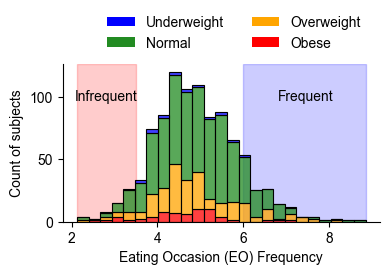

In [17]:
fig, ax = plt.subplots(figsize=(4, 3))

# Add shaded regions first (so they appear behind the histogram)
max_x = meta["eo_freq"].max()
min_x = meta["eo_freq"].min()
ax.axvspan(min_x, infrequent_cutoff, alpha=0.2, color="red")
ax.axvspan(frequent_cutoff, max_x, alpha=0.2, color="blue")

# Annotate the shaded region from 0 to 3.5 with 'Infrequent'
ax.text(
    2.8,
    ax.get_ylim()[1] * 100,
    "Infrequent",
    color="black",
    ha="center",
    va="center",
    fontsize="medium",
)
ax.text(
    7.45,
    ax.get_ylim()[1] * 100,
    "Frequent",
    color="black",
    ha="center",
    va="center",
    fontsize="medium",
)

# Create the histogram
colors = ["blue", "forestgreen", "orange", "red", "magenta"]
sns.histplot(
    data=meta,
    x="eo_freq",
    hue="bmi_cat",
    palette=colors,
    hue_order=["Underweight", "Normal", "Overweight", "Obese"],
    multiple="stack",
    ax=ax,
    bins=25,  # Reduce bin size
    legend=False,  # Turn off automatic legend
)

# Create custom legend elements
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor=colors[0], label="Underweight", linewidth=0.2),
    Patch(facecolor=colors[1], label="Normal", linewidth=0.2),
    Patch(facecolor=colors[2], label="Overweight", linewidth=0.2),
    Patch(facecolor=colors[3], label="Obese", linewidth=0.2),
]

ax.legend(
    handles=legend_elements,
    ncol=2,
    title="",
    loc="center left",
    bbox_to_anchor=(0.1, 1.2),
    frameon=False,
    fontsize="medium",
    title_fontsize="small",
)

ax.set_xlabel("Eating Occasion (EO) Frequency")
ax.set_ylabel("Count of subjects")
sns.despine()
plt.tight_layout()
fig.savefig(
    "../images/fig1/eo_freq_distribution_bmi.png",
    bbox_inches="tight",
    dpi=300,
)
plt.show()